# Machine Learning Preparation: Regular Sample vs Stratified Sample

This notebook continues the stratified sampling lesson by using the same rodent dataset and the same sampling idea in a small machine learning example.

The goal is to compare two training datasets:
- A **regular random sample** from the sampling frame
- A **stratified sample** with the same number of observations from each species

The model will try to predict **species_id**. The focus is not on building the best model. The focus is on seeing how the training data changes the results. If the training data is naturally imbalanced, the model sees common species more often. If the training data is stratified, the model sees each eligible species the same number of times.

---


## Load the data

This cell reads the merged project dataset. The lesson uses sklearn only as a tool for comparison, not as the main topic.


In [1]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from IPython.display import Image, display

RANDOM_SEED = 123
OBSERVATIONS_PER_SPECIES = 40
TEST_PERCENT = 0.20

# Load the merged project dataset
df = pd.read_csv('../../output/merged_full.csv')
df.head()


,record_id,month,day,year,plot_id,note1,species_id,sex,hindfoot_length,weight,genus,species_name,taxa,plot_type,note1_meaning
0,63,8,19,1977,3.0,NaN,DM,M,35.0,40.0,Dipodomys,merriami,Rodent,Long-term Krat Exclosure,NaN
1,64,8,19,1977,7.0,NaN,DM,M,37.0,48.0,Dipodomys,merriami,Rodent,Rodent Exclosure,NaN
2,65,8,19,1977,4.0,NaN,DM,F,34.0,29.0,Dipodomys,merriami,Rodent,Control,NaN
3,66,8,19,1977,4.0,NaN,DM,F,35.0,46.0,Dipodomys,merriami,Rodent,Control,NaN
4,67,8,19,1977,7.0,NaN,DM,M,35.0,36.0,Dipodomys,merriami,Rodent,Rodent Exclosure,NaN


The merged dataset includes species information, plot information, time columns, and measurement columns. For this notebook, **species_id** is the value being predicted. The other selected columns are simple predictors that were already available in the dataset.


## Prepare the machine learning dataset

This cell keeps the columns needed for the comparison and cleans the text columns in the same style as the stratified sampling notebook.


In [2]:
model_df = df[[
    'record_id',
    'year',
    'month',
    'species_id',
    'species_name',
    'sex',
    'plot_type',
    'hindfoot_length',
    'weight'
]].copy()

for col in ['species_id', 'species_name', 'sex', 'plot_type']:
    model_df[col] = model_df[col].astype('string').str.strip()

model_df = model_df.dropna(subset=['record_id', 'species_id', 'species_name']).copy()
model_df = model_df.loc[model_df['species_id'].ne('')].copy()

model_df.head()


,record_id,year,month,species_id,species_name,sex,plot_type,hindfoot_length,weight
0,63,1977,8,DM,merriami,M,Long-term Krat Exclosure,35.0,40.0
1,64,1977,8,DM,merriami,M,Rodent Exclosure,37.0,48.0
2,65,1977,8,DM,merriami,F,Control,34.0,29.0
3,66,1977,8,DM,merriami,F,Control,35.0,46.0
4,67,1977,8,DM,merriami,M,Rodent Exclosure,35.0,36.0


This smaller dataset keeps the lesson focused. It does not remove rows just because one measurement is missing, because the model pipeline below can fill missing numeric values with the median and missing category values with the most common value.

That setup keeps the comparison about sampling instead of turning it into a lesson about data cleaning.


## Create the same sampling frame as the stratified lesson

The previous notebook used 40 observations per species. This notebook keeps that same rule so the two lessons connect directly.


In [3]:
species_counts = (
    model_df.groupby(['species_id', 'species_name'], as_index=False)
    .size()
    .rename(columns={'size': 'full_dataset_count'})
    .sort_values('full_dataset_count', ascending=False)
)

species_counts['full_dataset_percent'] = (
    species_counts['full_dataset_count'] / species_counts['full_dataset_count'].sum()
)

eligible_species = species_counts.loc[
    species_counts['full_dataset_count'] >= OBSERVATIONS_PER_SPECIES,
    'species_id'
]

sampling_frame = model_df[model_df['species_id'].isin(eligible_species)].copy()

print(f'There are {len(sampling_frame)} observations in the sampling frame')
print(f'There are {sampling_frame["species_id"].nunique()} eligible species')

species_counts[species_counts['species_id'].isin(eligible_species)].head()


There are 70902 observations in the sampling frame
There are 20 eligible species


,species_id,species_name,full_dataset_count,full_dataset_percent
15,PP,penicillatus,18565,0.261785
1,DM,merriami,17546,0.247416
8,PB,baileyi,10427,0.147031
2,DO,ordii,5459,0.076977
6,OT,torridus,4320,0.060916


The sampling frame is the same idea as before, it keeps the species that have enough observations for the equal-size stratified sample.

The counts are still uneven. That unevenness is what makes the regular sample and the stratified sample teach different things to the model.


## Set aside one shared test dataset

To compare the two training samples fairly, both models need to be checked against the same rows. This cell sets aside a test dataset first, then builds the training samples from the remaining rows.

The test dataset is a regular random sample from the sampling frame. It represents the naturally imbalanced data, which is useful here because we want to see how each training sample behaves when it is evaluated against regular data.


In [4]:
test_df = sampling_frame.sample(
    frac=TEST_PERCENT,
    random_state=RANDOM_SEED
).copy()

train_pool = sampling_frame.drop(index=test_df.index).copy()

train_species_counts = train_pool['species_id'].value_counts()
eligible_train_species = train_species_counts[
    train_species_counts >= OBSERVATIONS_PER_SPECIES
].index

train_pool = train_pool[train_pool['species_id'].isin(eligible_train_species)].copy()
test_df = test_df[test_df['species_id'].isin(eligible_train_species)].copy()

n_species = train_pool['species_id'].nunique()
total_sample_size = n_species * OBSERVATIONS_PER_SPECIES

print(f'There are {len(train_pool)} observations available for training samples')
print(f'There are {len(test_df)} observations in the shared test dataset')
print(f'There are {n_species} species that can still provide {OBSERVATIONS_PER_SPECIES} training rows')
print(f'Each training sample will contain {total_sample_size} observations')


There are 56660 observations available for training samples
There are 14160 observations in the shared test dataset
There are 18 species that can still provide 40 training rows
Each training sample will contain 720 observations


The test set is held constant. The only thing that changes is the data used for training.

This is the key setup for the lesson. If the results differ, the difference is coming from what each model saw during training.


## Create the two training samples

This cell creates one regular random training sample and one stratified training sample. Both samples have the same total number of observations.


In [5]:
regular_train = train_pool.sample(
    n=total_sample_size,
    random_state=RANDOM_SEED
).reset_index(drop=True)

stratified_train = (
    train_pool
    .groupby('species_id', group_keys=False)
    .sample(n=OBSERVATIONS_PER_SPECIES, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

print(f'Regular training sample rows: {len(regular_train)}')
print(f'Stratified training sample rows: {len(stratified_train)}')


Regular training sample rows: 720
Stratified training sample rows: 720


The regular sample lets common species appear more often because those species have more rows in the training pool.

The stratified sample forces every eligible species to appear exactly 40 times. That is useful for comparing species, but it no longer matches the natural proportions of the dataset.


## Compare species representation in the training data

Before training a model, we should look at what each model is going to learn from. This table compares the species counts in the training pool, the regular training sample, and the stratified training sample.


In [6]:
training_representation = pd.DataFrame({
    'training_pool_count': train_pool['species_id'].value_counts(),
    'regular_train_count': regular_train['species_id'].value_counts(),
    'stratified_train_count': stratified_train['species_id'].value_counts(),
    'training_pool_percent': train_pool['species_id'].value_counts(normalize=True),
    'regular_train_percent': regular_train['species_id'].value_counts(normalize=True),
    'stratified_train_percent': stratified_train['species_id'].value_counts(normalize=True)
}).fillna(0)

count_columns = ['training_pool_count', 'regular_train_count', 'stratified_train_count']
training_representation[count_columns] = training_representation[count_columns].astype(int)
training_representation = training_representation.sort_values('training_pool_count', ascending=False)

training_representation


,training_pool_count,regular_train_count,stratified_train_count,training_pool_percent,regular_train_percent,stratified_train_percent
species_id,,,,,,
PP,14871,200,40,0.26246,0.277778,0.055556
DM,14014,178,40,0.247335,0.247222,0.055556
PB,8321,91,40,0.146858,0.126389,0.055556
DO,4368,58,40,0.077091,0.080556,0.055556
OT,3452,38,40,0.060925,0.052778,0.055556
RM,2819,41,40,0.049753,0.056944,0.055556
PE,2224,34,40,0.039252,0.047222,0.055556
DS,1668,19,40,0.029439,0.026389,0.055556
PF,1601,19,40,0.028256,0.026389,0.055556


This table is the most important part of the setup. The model trained on the regular sample will see some species many times and other species only a few times. The model trained on the stratified sample will see every species the same number of times.

That difference can change which species the model predicts well.


## Visualize the training samples

This chart shows how different the two training samples are, even though they contain the same total number of rows.


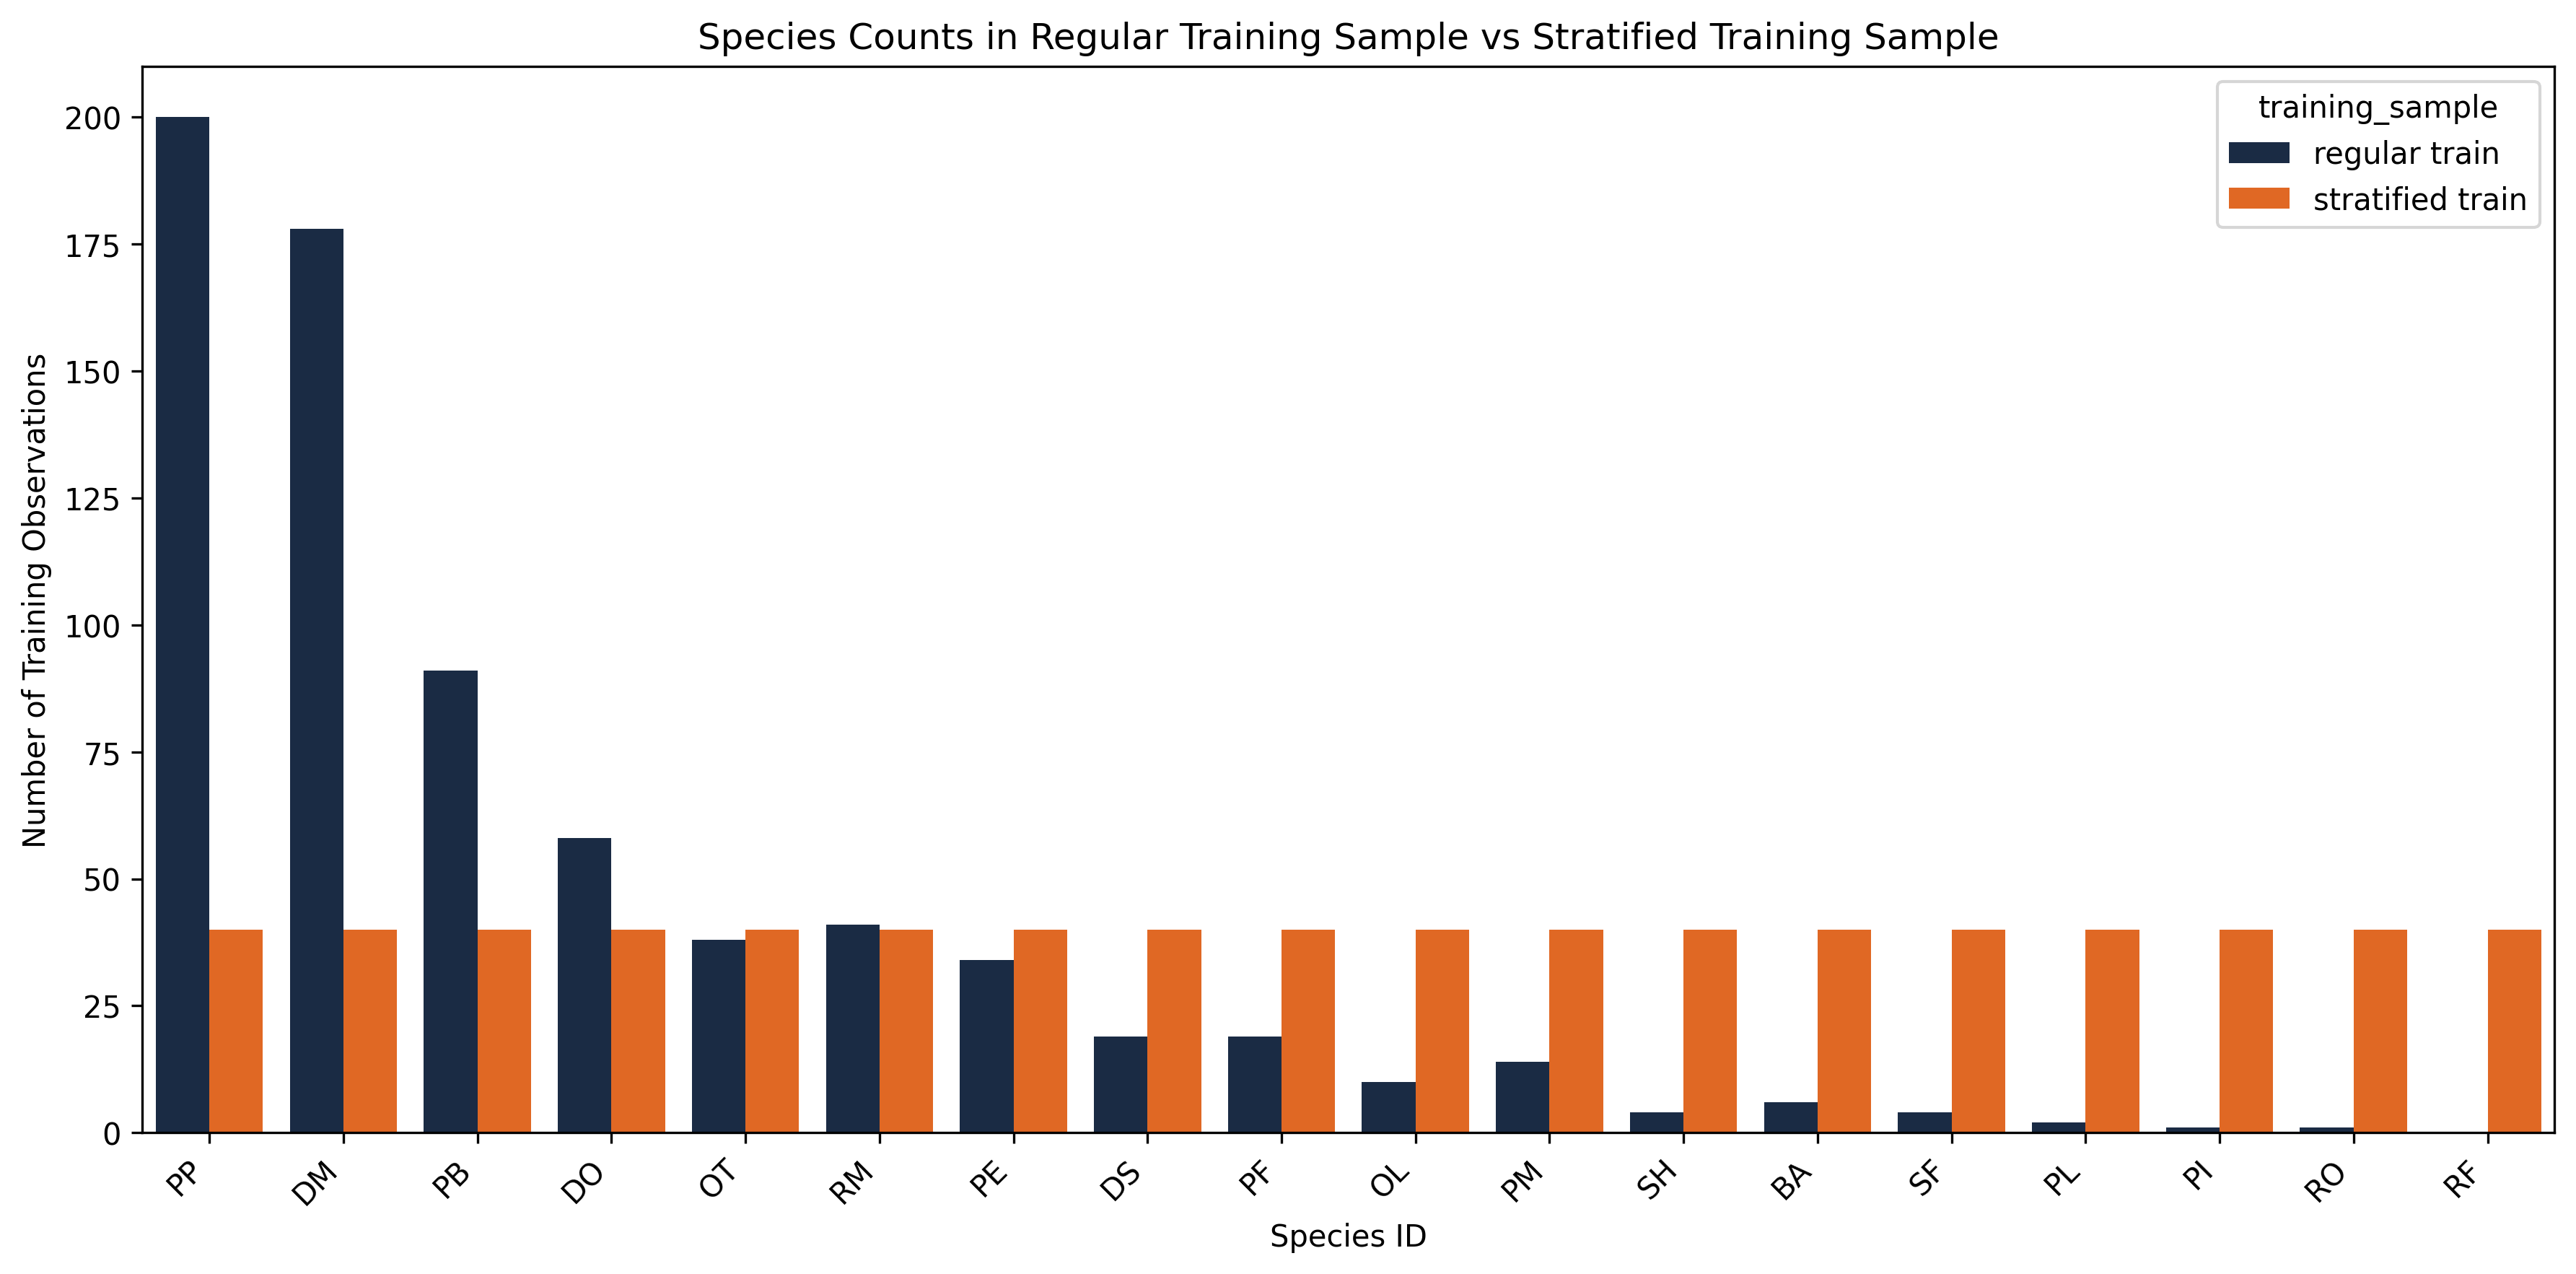

In [7]:

# FIG 5.1
display(Image(filename="../../images/fig_5_1.png"))


The regular sample is uneven because it follows the uneven data. The stratified sample is flat because it was designed that way.

The next section uses these two samples to train the same kind of model.


## Train the same simple model on each sample

This cell builds one simple sklearn pipeline and uses it twice. The model type, predictor columns, and test data stay the same. Only the training data changes.

The model is a basic decision tree. We are not tuning it or trying to make it the best possible model. It is only here to show how the training sample can change the results.


In [8]:
feature_columns = ['year', 'month', 'sex', 'plot_type', 'hindfoot_length', 'weight']
target_column = 'species_id'

numeric_features = ['year', 'month', 'hindfoot_length', 'weight']
categorical_features = ['sex', 'plot_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', SimpleImputer(strategy='median'), numeric_features),
        ('categorical', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('one_hot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

def build_model():
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            max_depth=6,
            random_state=RANDOM_SEED
        ))
    ])

regular_model = build_model()
stratified_model = build_model()

regular_model.fit(regular_train[feature_columns], regular_train[target_column])
stratified_model.fit(stratified_train[feature_columns], stratified_train[target_column])

print('Both models were trained with the same sklearn setup.')


Both models were trained with the same sklearn setup.

The exact model is less important than the comparison. Since the setup is the same for both models, differences in the results should be read as differences connected to the training sample.


## Compare overall accuracy on the shared test data

Accuracy is the percent of test rows where the predicted species matches the real species. It is useful as a quick summary, but it can hide what happens to smaller species groups.


In [9]:
regular_predictions = regular_model.predict(test_df[feature_columns])
stratified_predictions = stratified_model.predict(test_df[feature_columns])

overall_results = pd.DataFrame({
    'training_sample': ['regular_train', 'stratified_train'],
    'training_rows': [len(regular_train), len(stratified_train)],
    'test_rows': [len(test_df), len(test_df)],
    'overall_accuracy': [
        accuracy_score(test_df[target_column], regular_predictions),
        accuracy_score(test_df[target_column], stratified_predictions)
    ]
})

overall_results


,training_sample,training_rows,test_rows,overall_accuracy
0,regular_train,720,14160,0.775353
1,stratified_train,720,14160,0.466667


A higher overall accuracy does not automatically mean the training sample is better for every question.

Because the test data is naturally imbalanced, common species have more influence on the overall accuracy. A model can score well overall while still doing poorly on rare species.


## Compare results by species

This cell calculates recall for each species. Recall answers this question: **Of the rows that really belong to this species, what percent did the model correctly identify?**

This is still a light interpretation. We are using the metric only to see whether the two training samples behave differently across species.


In [10]:
regular_report = classification_report(
    test_df[target_column],
    regular_predictions,
    output_dict=True,
    zero_division=0
)

stratified_report = classification_report(
    test_df[target_column],
    stratified_predictions,
    output_dict=True,
    zero_division=0
)

species_labels = sorted(test_df[target_column].unique())

species_results = pd.DataFrame({
    'species_id': species_labels,
    'test_count': [int((test_df[target_column] == species).sum()) for species in species_labels],
    'regular_train_count': [int((regular_train[target_column] == species).sum()) for species in species_labels],
    'stratified_train_count': [int((stratified_train[target_column] == species).sum()) for species in species_labels],
    'regular_recall': [regular_report[species]['recall'] for species in species_labels],
    'stratified_recall': [stratified_report[species]['recall'] for species in species_labels]
})

species_results['recall_difference'] = (
    species_results['stratified_recall'] - species_results['regular_recall']
)

species_results.sort_values('test_count', ascending=False)


,species_id,test_count,regular_train_count,stratified_train_count,regular_recall,stratified_recall,recall_difference
12,PP,3694,200,40,0.897401,0.371142,-0.526259
1,DM,3532,178,40,0.954417,0.507361,-0.447055
6,PB,2106,91,40,0.920703,0.903134,-0.017569
2,DO,1091,58,40,0.198900,0.681027,0.482126
5,OT,868,38,40,0.752304,0.000000,-0.752304
14,RM,712,41,40,0.831461,0.000000,-0.831461
7,PE,551,34,40,0.094374,0.000000,-0.094374
3,DS,426,19,40,1.000000,0.978873,-0.021127
8,PF,390,19,40,0.594872,0.000000,-0.594872
4,OL,272,10,40,0.088235,0.599265,0.511029


This table connects the model results back to sampling. The regular training sample may have more rows for common species, while the stratified training sample gives every species the same number of rows.

The recall columns show whether that difference changes how often each species is correctly identified in the shared test set.


## Visualize species-level recall

This chart compares recall by species for the two training samples.


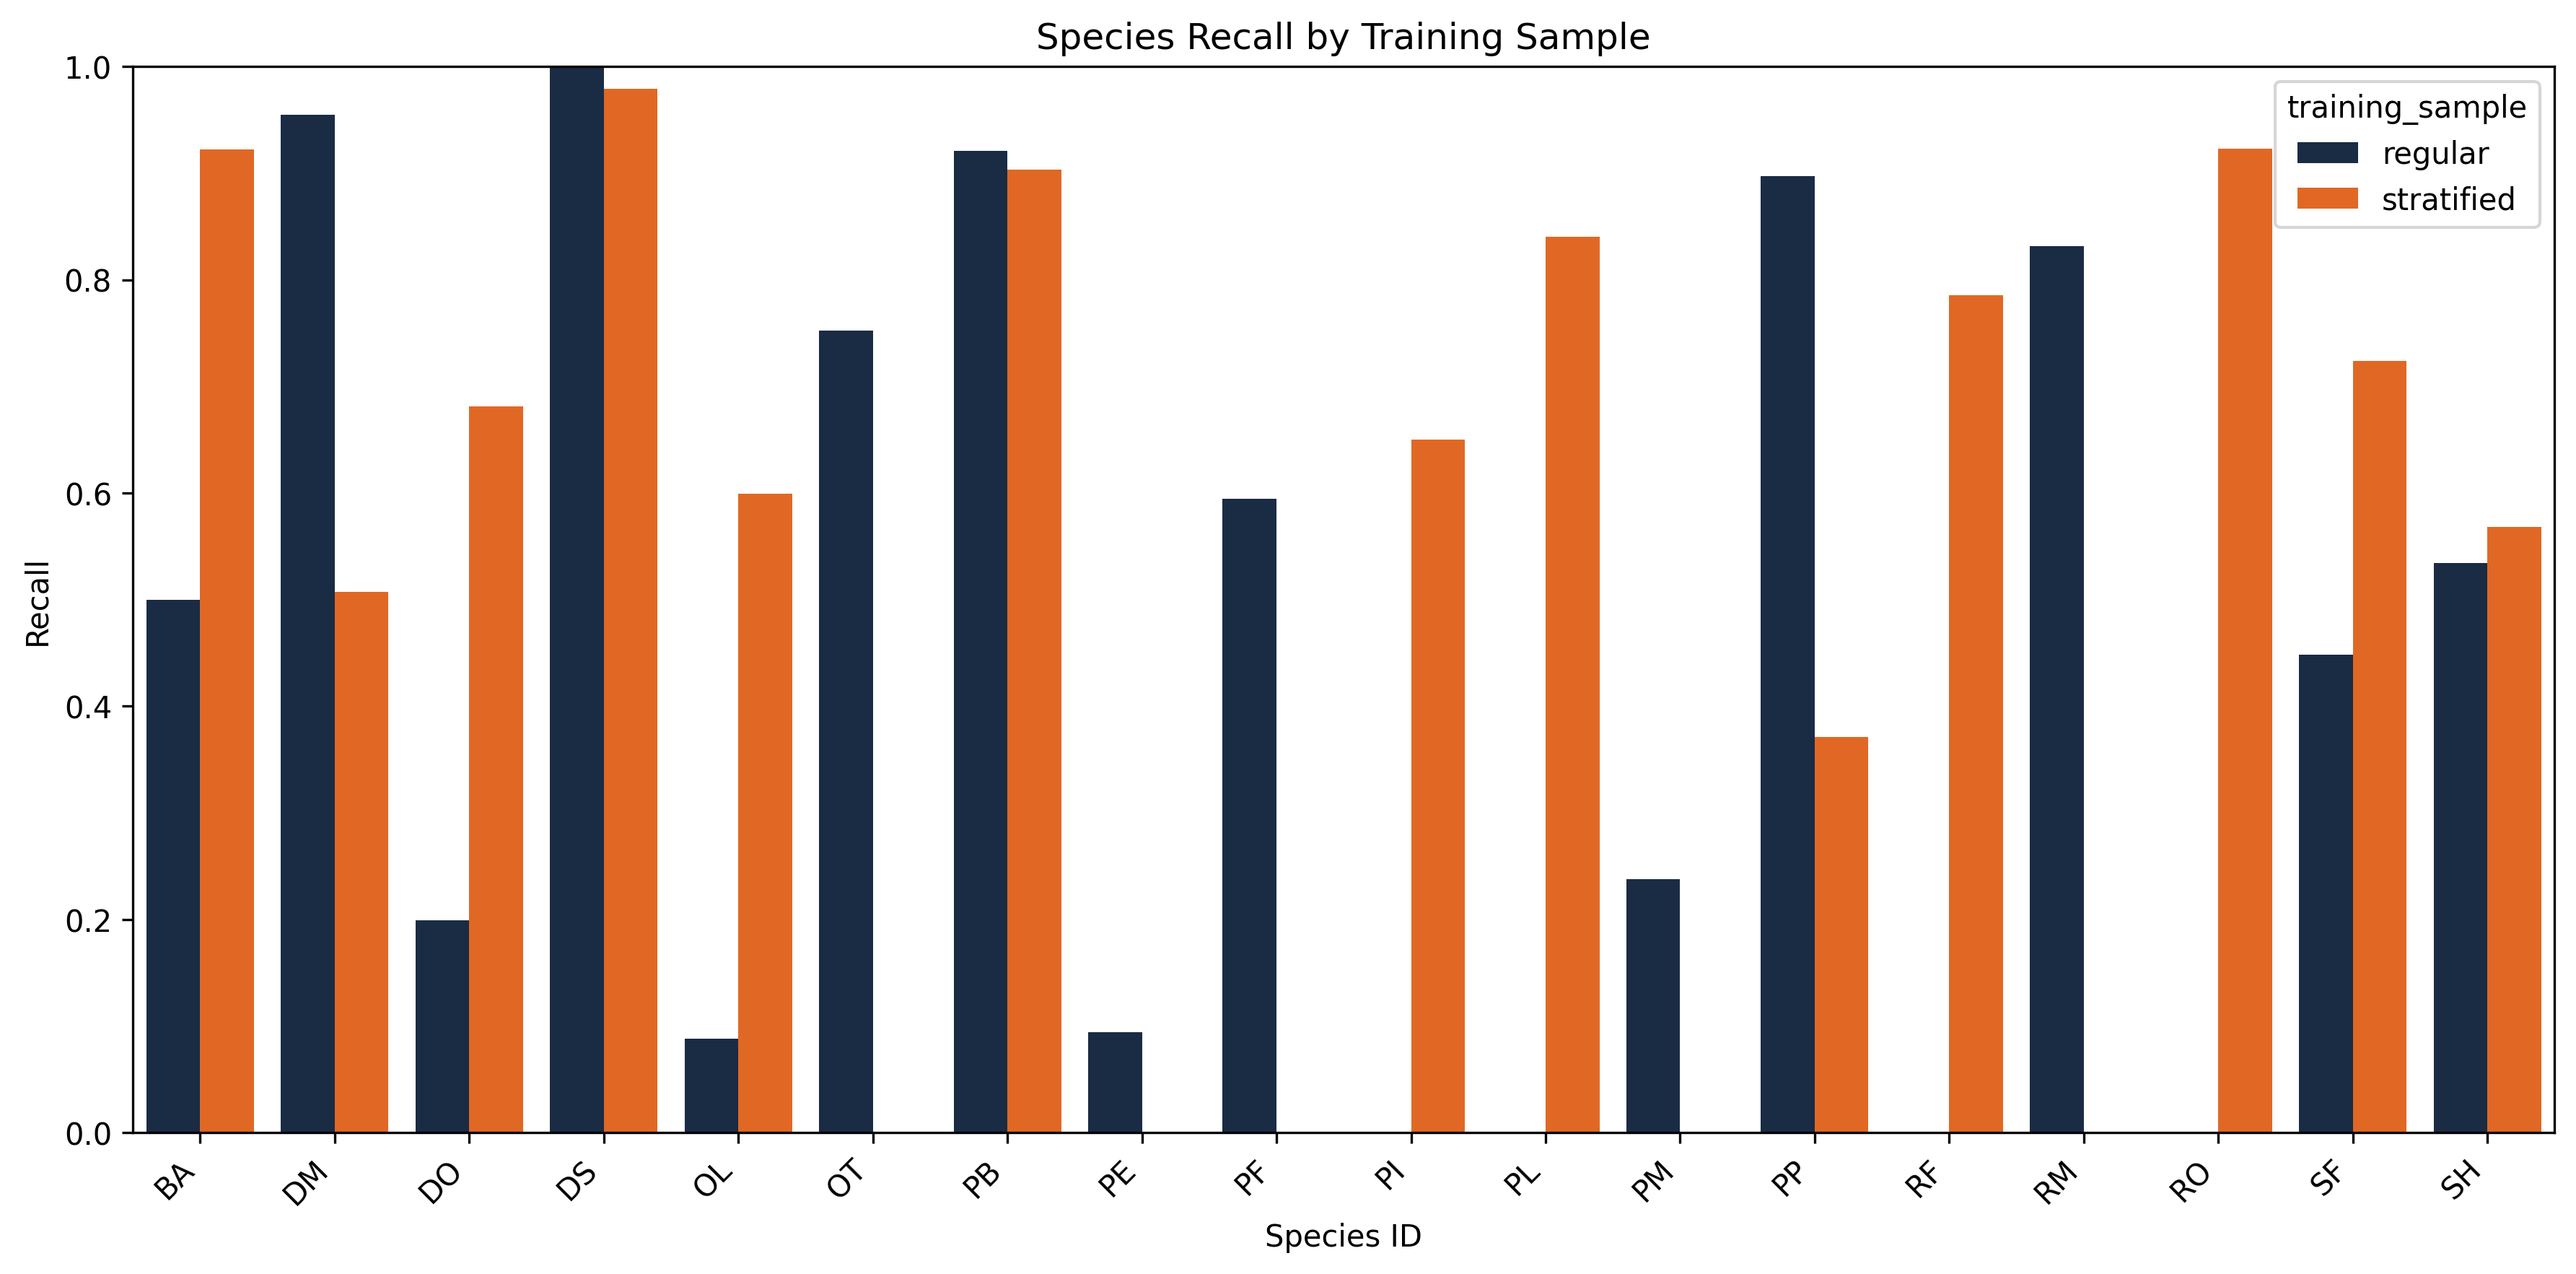

In [11]:

# FIG 5.2
display(Image(filename="../../images/fig_5_2.png"))


The model trained on the regular sample is influenced by the species mix it saw during training. The model trained on the stratified sample is influenced by the equal species counts it saw during training.

Neither result should be treated as the final answer by itself. The important lesson is that changing the sample can change the model behavior.


## Compare predicted species counts

Another way to see the effect is to count what each model predicts. If a model predicts common species much more often, that may reflect the training data it saw.


In [12]:
prediction_counts = pd.DataFrame({
    'actual_test_count': test_df[target_column].value_counts(),
    'regular_prediction_count': pd.Series(regular_predictions).value_counts(),
    'stratified_prediction_count': pd.Series(stratified_predictions).value_counts()
}).fillna(0).astype(int)

prediction_counts = prediction_counts.sort_values('actual_test_count', ascending=False)
prediction_counts


,actual_test_count,regular_prediction_count,stratified_prediction_count
PP,3694,3723,1452
DM,3532,4240,2067
PB,2106,1999,2029
DO,1091,375,2398
OT,868,1548,0
RM,712,878,0
PE,551,148,0
DS,426,431,419
PF,390,323,0
OL,272,58,297


The prediction counts do not need to match perfectly. The useful question is whether the predictions lean toward the species that were more common in the training data.

This keeps the interpretation tied to sampling, not to model tuning.


## Conclusion

The same model can behave differently when it is trained on differently sampled data.

**Regular training sample**
- follows the natural imbalance in the data
- gives common species more influence during training
- may fit the overall test distribution better when the test data is also regular and imbalanced

**Stratified training sample**
- gives each eligible species the same number of training rows
- gives rare species more presence during training
- may change species-level results because the model sees a more balanced version of the data

The main point is not that one sample is always better. The main point is that sampling is part of the analysis. Before training a model, we should ask what the training data represents and whether that matches the question being asked.
